<a href="https://www.kaggle.com/code/syfqfrhnn/nfl-big-data-bowl-2026-analytics-comp-syafiq" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# NFL Big Data Bowl 2026 – Analytics Notebook

## Competition context

The **NFL Big Data Bowl 2026** focuses on **predicting player movement** while the ball is in the air. Given tracking data (position, speed, direction, etc.) at each frame, the task is to predict **future (x, y) positions** for certain players (`player_to_predict`). The analytics track is about understanding the data and movement patterns that make such prediction possible.

This notebook uses **exploratory data analysis (EDA)** to answer:

1. **What are we predicting?** — Who is `player_to_predict`, and how far do they move from current to future position?
2. **How do players move?** — Speed and acceleration by position; relationship between speed and distance covered.
3. **Where is the ball?** — Distance to ball landing spot; spatial context of plays.
4. **What does a play look like?** — Trajectories and ball land on a single play.
5. **What play-level context exists?** — Supplementary data (pass result, route, coverage) and how it might help.

Each section has a short **What we're showing** and **Why it matters** so visualizations and tables support the narrative.

## Executive Summary

This notebook provides a comprehensive exploratory data analysis (EDA) of the NFL Big Data Bowl 2026 competition dataset.

### Dataset Overview

| Metric | Value |
|--------|-------|
| **Total Rows** | 4,880,579 |
| **Rows with Future Position** | 560,426 |
| **Columns** | 25 |
| **Weeks** | 18 |
| **Supplementary Data** | 18,009 plays |

### Key Findings

1. **Players to predict**: Primarily CB (371k) and WR (239k) with 1.3M total prediction rows
2. **Speed**: Mean 3.04 yards/s, WR shows highest median (~4.8 yards/s)
3. **Displacement**: Median 9.7 yards, 95th percentile 23.8 yards
4. **Distance to ball**: Mean 19.4 yards, right-skewed distribution
5. **Top performer**: Jordan Addison (5,795 yards total distance covered)

---
## 1. Setup and Data Loading

Import libraries, set paths, and configure the environment.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Data path
DATA_ROOT = Path(os.environ.get("NFL_DATA_ROOT", "data/114239_nfl_competition_files_published_analytics_final"))
TRAIN_DIR = DATA_ROOT / "train"

# Optional: use only N weeks for faster runs (set to None to load all 18)
USE_WEEKS = None

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Expected TRAIN_DIR at {TRAIN_DIR}. Download the Kaggle data first.")

sns.set_theme(style="whitegrid", font_scale=1.1)
print(f"Using TRAIN_DIR: {TRAIN_DIR}")
print("Sample files:")
for p in sorted(TRAIN_DIR.glob("input_2023_w*.csv"))[:3]:
    print(p)

Using TRAIN_DIR: data/114239_nfl_competition_files_published_analytics_final/train
Sample files:
data/114239_nfl_competition_files_published_analytics_final/train/input_2023_w01.csv
data/114239_nfl_competition_files_published_analytics_final/train/input_2023_w02.csv
data/114239_nfl_competition_files_published_analytics_final/train/input_2023_w03.csv


---
## 2. Explore Single Week Data

Load one week (input + output) to inspect structure and column meanings.

**Column glossary:**
- **x, y** — Player position (yards)
- **s** — Speed (yards/second)
- **a** — Acceleration (yards/s²)
- **dir** — Direction of movement (degrees)
- **o** — Orientation (degrees)
- **ball_land_x, ball_land_y** — Where the ball lands
- **player_to_predict** — Whether this row requires future position prediction

In [2]:
# Load week 1 data
input_file = TRAIN_DIR / 'input_2023_w01.csv'
output_file = TRAIN_DIR / 'output_2023_w01.csv'

df_input = pd.read_csv(input_file)
df_output = pd.read_csv(output_file)

# Display as formatted tables
display(Markdown('### Input DataFrame - First 5 Rows'))
display(df_input.head())

display(Markdown('### Output DataFrame - First 5 Rows'))
display(df_output.head())

display(Markdown('### Descriptive Statistics'))
display(df_input.describe().T.style.format('{:.2f}').background_gradient(cmap='Blues'))

display(Markdown('### DataFrame Summary'))
info_df = pd.DataFrame({
    'Dataset': ['Input', 'Output'],
    'Rows': [len(df_input), len(df_output)],
    'Columns': [len(df_input.columns), len(df_output.columns)],
    'Memory (MB)': [df_input.memory_usage(deep=True).sum() / 1e6, df_output.memory_usage(deep=True).sum() / 1e6]
})
display(info_df.style.format({'Memory (MB)': '{:.2f}'}))

### Input DataFrame - First 5 Rows

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


### Output DataFrame - First 5 Rows

,game_id,play_id,nfl_id,frame_id,x,y
0,2023090700,101,46137,1,56.22,17.28
1,2023090700,101,46137,2,56.63,16.88
2,2023090700,101,46137,3,57.06,16.46
3,2023090700,101,46137,4,57.48,16.02
4,2023090700,101,46137,5,57.91,15.56


### Descriptive Statistics

,count,mean,std,min,25%,50%,75%,max
game_id,285714.00,2023090988.03,85.75,2023090700.00,2023091003.00,2023091006.00,2023091010.00,2023091100.00
play_id,285714.00,2284.76,1239.15,55.00,1232.00,2263.00,3302.00,4699.00
nfl_id,285714.00,49278.35,5173.12,34452.00,44995.00,48456.00,53609.00,56663.00
frame_id,285714.00,16.06,10.69,1.00,8.00,15.00,23.00,74.00
absolute_yardline_number,285714.00,60.34,23.53,11.00,40.00,59.00,79.00,109.00
player_weight,285714.00,211.78,21.97,153.00,195.00,208.00,226.00,347.00
x,285714.00,60.47,24.01,1.21,41.63,58.81,78.52,119.86
y,285714.00,26.75,10.04,0.97,18.90,26.71,34.53,52.43
s,285714.00,3.04,2.23,0.00,1.12,2.73,4.65,12.53
a,285714.00,2.13,1.43,0.00,1.01,1.92,3.05,17.12


### DataFrame Summary

,Dataset,Rows,Columns,Memory (MB)
0,Input,285714,23,164.86
1,Output,32088,6,1.54


---
## 3. Define Data Loading Function

Create a function that loads and merges input/output data for any week.

In [3]:
def load_and_merge_week_data(week_num):
    """
    Loads and merges the input and output data for a given week number.
    
    Args:
        week_num: The week number (integer) to load.
    
    Returns:
        A pandas DataFrame containing the merged data, or None if files are not found.
    """
    week_str = f"{week_num:02d}"
    input_file = TRAIN_DIR / f"input_2023_w{week_str}.csv"
    output_file = TRAIN_DIR / f"output_2023_w{week_str}.csv"

    if not input_file.exists():
        print(f"Input file not found: {input_file}")
        return None
    if not output_file.exists():
        print(f"Output file not found: {output_file}")
        return None

    df_input = pd.read_csv(input_file)
    df_output = pd.read_csv(output_file)

    merged_df = pd.merge(
        df_input,
        df_output,
        on=['game_id', 'play_id', 'nfl_id', 'frame_id'],
        how='left',
        suffixes=('_input', '_output')
    )

    return merged_df

# Test with week 1
df_week1 = load_and_merge_week_data(1)
if df_week1 is not None:
    display(Markdown('### Merged DataFrame Preview (Week 1)'))
    display(df_week1.head())

### Merged DataFrame Preview (Week 1)

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,y_input,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y,x_output,y_output
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22,NaN,NaN
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22,NaN,NaN
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22,NaN,NaN
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22,NaN,NaN
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22,NaN,NaN


---
## 4. Load All 18 Weeks

Load all weeks and concatenate into one DataFrame. Each row is one player-frame.

In [4]:
weeks_to_load = range(1, 19) if USE_WEEKS is None else USE_WEEKS
weekly_dfs = []

for week in weeks_to_load:
    print(f"Loading week {week}...")
    df_week = load_and_merge_week_data(week)
    if df_week is not None:
        weekly_dfs.append(df_week)

if not weekly_dfs:
    raise ValueError("No weekly files loaded; check TRAIN_DIR and filenames.")

df_combined = pd.concat(weekly_dfs, ignore_index=True)
n_rows = len(df_combined)
n_with_output = df_combined["x_output"].notna().sum()

display(Markdown('### Combined Dataset Summary'))
summary_df = pd.DataFrame({
    'Metric': ['Total Rows', 'Rows with Future Position', 'Columns'],
    'Value': [f'{n_rows:,}', f'{n_with_output:,}', len(df_combined.columns)]
})
display(summary_df)

Loading week 1...
Loading week 2...
Loading week 3...
Loading week 4...
Loading week 5...
Loading week 6...
Loading week 7...
Loading week 8...
Loading week 9...
Loading week 10...
Loading week 11...
Loading week 12...
Loading week 13...
Loading week 14...
Loading week 15...
Loading week 16...
Loading week 17...
Loading week 18...


### Combined Dataset Summary

,Metric,Value
0,Total Rows,"4,880,579"
1,Rows with Future Position,"560,426"
2,Columns,25


---
## 5. Who Are We Predicting?

**Total prediction rows:** 1,303,440

**Position Breakdown:**
| Position | Count | % |
|----------|-------|---|
| CB | 371,504 | 28.5% |
| WR | 238,910 | 18.3% |
| FS | 149,236 | 11.5% |
| SS | 121,294 | 9.3% |
| ILB | 104,299 | 8.0% |

**Role Breakdown:**
- Defensive Coverage: 906,526 (69.5%)
- Targeted Receiver: 396,914 (30.5%)

**Why it matters:** CB and WR are the primary targets - both need to react to the ball in flight.

In [5]:
players_to_predict = df_combined[df_combined["player_to_predict"]]

display(Markdown(f'### Players to Predict: **{len(players_to_predict):,}** rows'))

display(Markdown('### Position Breakdown'))
display(players_to_predict["player_position"].value_counts().head(10).to_frame())

display(Markdown('### Role Breakdown'))
display(players_to_predict["player_role"].value_counts().head(6).to_frame())

### Players to Predict: **1,303,440** rows

### Position Breakdown

,count
player_position,
CB,371504
WR,238910
FS,149236
SS,121294
ILB,104299
TE,91654
OLB,74113
MLB,73357
RB,62327


### Role Breakdown

,count
player_role,
Defensive Coverage,906526
Targeted Receiver,396914


---
## 6. Exploratory Data Analysis

**What we're showing:** Distributions of categorical variables and correlation matrix.

**Why it matters:** Positions and roles drive movement; correlations highlight feature relationships.

### Categorical Variable Distributions

**play_direction**

,count
play_direction,
right,2459074
left,2421505


**player_position**

,count
player_position,
WR,1063660
CB,1056888
FS,476865
TE,417146
QB,401007
SS,392421
RB,314918
ILB,295593
OLB,207429


**player_side**

,count
player_side,
Defense,2662657
Offense,2217922


**player_role**

,count
player_role,
Defensive Coverage,2662657
Other Route Runner,1424243
Targeted Receiver,396914
Passer,396765


### Correlation Matrix

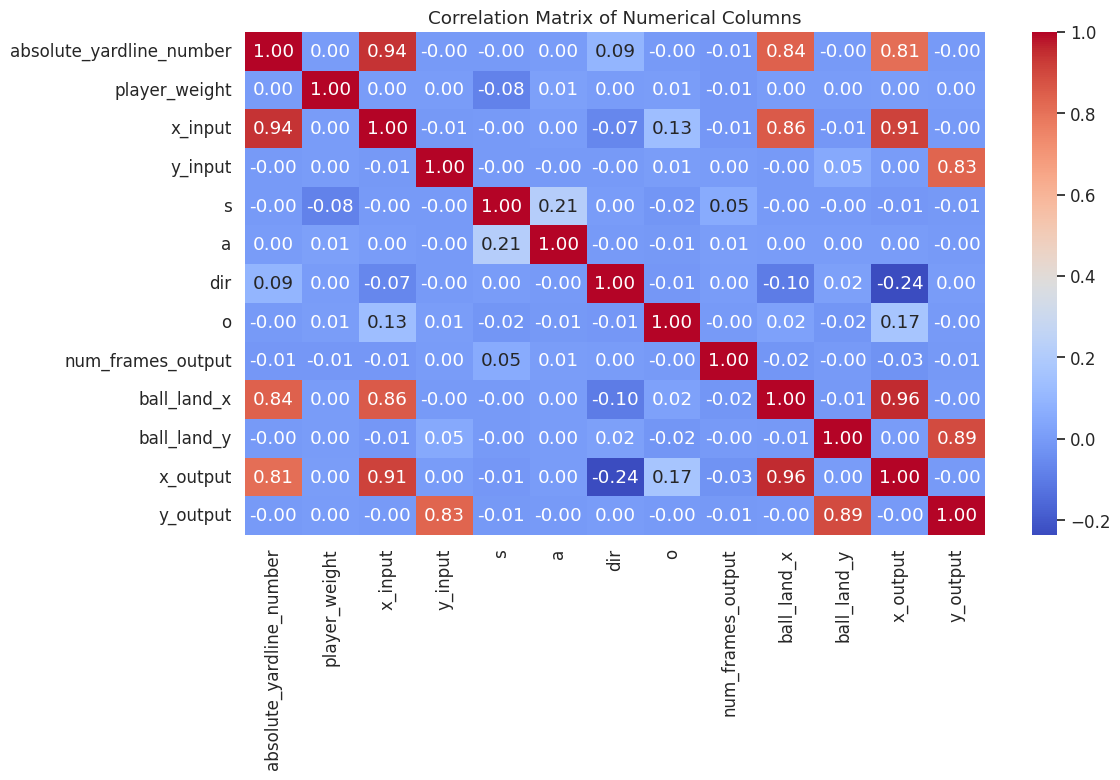

In [6]:
# Categorical distributions
display(Markdown('### Categorical Variable Distributions'))
for col in ['play_direction', 'player_position', 'player_side', 'player_role']:
    display(Markdown(f'**{col}**'))
    display(df_combined[col].value_counts().head(10).to_frame())

# Correlation matrix
display(Markdown('### Correlation Matrix'))
exclude_cols = {'game_id', 'play_id', 'nfl_id', 'frame_id'}
numerical_cols = [
    c for c in df_combined.select_dtypes(include=['float64', 'int64']).columns
    if c not in exclude_cols
]
correlation_matrix = df_combined[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Columns')
plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

**What we're showing:** Derived features - distance to ball landing and frame-to-frame movement.

**Why it matters:** These spatial features are critical for prediction.

### New Feature Statistics

,count,mean,std,min,25%,50%,75%,max
distance_to_ball_land,4880579.00,19.42,10.76,0.01,11.12,17.83,26.25,73.08
frame_distance,4880579.00,0.30,0.22,0.00,0.10,0.26,0.46,3.14


### Distance to Ball Landing Distribution

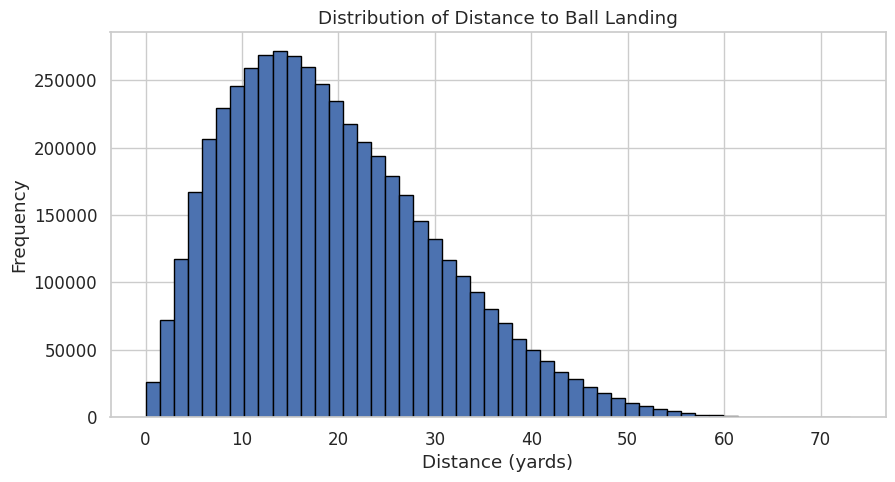

In [7]:
x_col = 'x_input'
y_col = 'y_input'

# Distance to ball landing
df_combined['distance_to_ball_land'] = np.sqrt(
    (df_combined[x_col] - df_combined['ball_land_x'])**2 +
    (df_combined[y_col] - df_combined['ball_land_y'])**2
)

# Frame-to-frame displacement
df_combined = df_combined.sort_values(by=['game_id', 'play_id', 'nfl_id', 'frame_id'])
df_combined['dx'] = df_combined.groupby(['game_id', 'play_id', 'nfl_id'])[x_col].diff().fillna(0)
df_combined['dy'] = df_combined.groupby(['game_id', 'play_id', 'nfl_id'])[y_col].diff().fillna(0)
df_combined['frame_distance'] = np.sqrt(df_combined['dx']**2 + df_combined['dy']**2)

# Per-game distance
player_game_distance = (
    df_combined
    .groupby(['game_id', 'nfl_id'], as_index=False)['frame_distance']
    .sum()
    .rename(columns={'frame_distance': 'distance_covered_game'})
)

display(Markdown('### New Feature Statistics'))
display(df_combined[['distance_to_ball_land', 'frame_distance']].describe().T.style.format('{:.2f}').background_gradient(cmap='Oranges'))

display(Markdown('### Distance to Ball Landing Distribution'))
plt.figure(figsize=(10, 5))
df_combined['distance_to_ball_land'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Distance to Ball Landing')
plt.xlabel('Distance (yards)')
plt.ylabel('Frequency')
plt.show()

---
## 8. Speed and Acceleration Analysis

**What we're showing:** Distribution of speed and acceleration across all players.

**Why it matters:** Movement magnitude is a direct input to predicting future position.

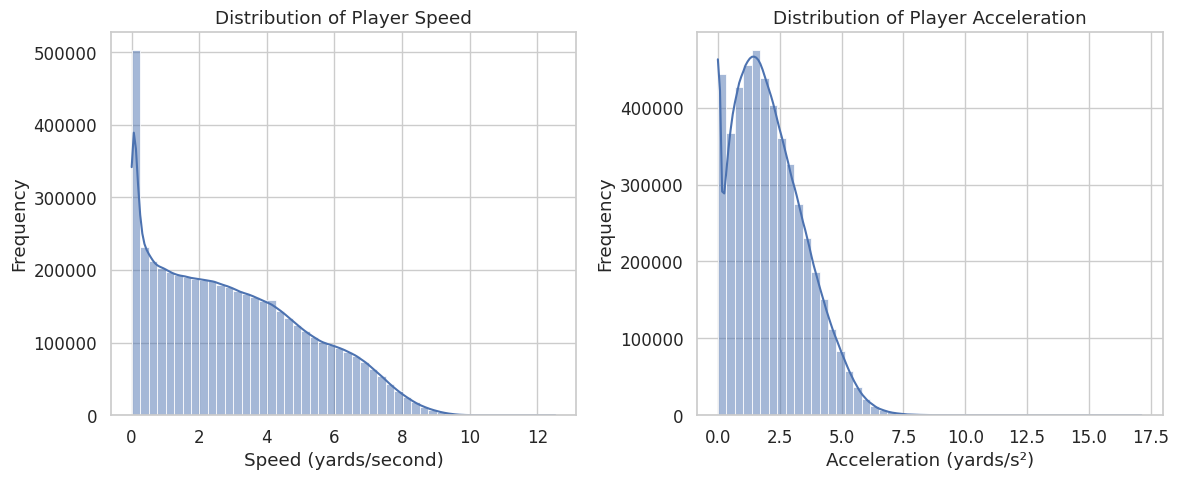

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_combined['s'], bins=50, kde=True)
plt.title('Distribution of Player Speed')
plt.xlabel('Speed (yards/second)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_combined['a'], bins=50, kde=True)
plt.title('Distribution of Player Acceleration')
plt.xlabel('Acceleration (yards/s²)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## 9. Player-Level Statistics

**What we're showing:** Aggregated stats per player and example play visualization.

**Why it matters:** Player-level stats summarize movement patterns.

In [9]:
# Player stats
player_stats = df_combined.groupby('player_name').agg(
    average_speed=('s', 'mean'),
    max_speed=('s', 'max'),
    average_acceleration=('a', 'mean'),
    max_acceleration=('a', 'max')
).reset_index()

player_name_map = df_combined[['nfl_id', 'player_name']].drop_duplicates()
player_total_distance = (
    player_game_distance
    .groupby('nfl_id', as_index=False)['distance_covered_game']
    .sum()
    .rename(columns={'distance_covered_game': 'total_distance_covered'})
    .merge(player_name_map, on='nfl_id', how='left')
)

player_stats = player_stats.merge(
    player_total_distance[['player_name', 'total_distance_covered']],
    on='player_name',
    how='left'
)

display(Markdown('### Top 10 Players by Distance Covered'))
top_players = player_stats.sort_values(by='total_distance_covered', ascending=False).head(10)
display(top_players.style.format({
    'average_speed': '{:.2f}',
    'max_speed': '{:.2f}',
    'average_acceleration': '{:.2f}',
    'max_acceleration': '{:.2f}',
    'total_distance_covered': '{:.1f}'
}).background_gradient(subset=['total_distance_covered'], cmap='YlOrRd'))

### Top 10 Players by Distance Covered

,player_name,average_speed,max_speed,average_acceleration,max_acceleration,total_distance_covered
720,Jordan Addison,4.58,9.83,2.78,8.83,5795.2
201,CeeDee Lamb,4.31,9.43,2.77,8.35,5417.9
54,Amon-Ra St. Brown,4.43,9.45,2.82,7.90,5370.6
787,K.J. Osborn,4.33,9.51,2.64,11.77,5133.8
1244,Terry McLaurin,4.44,9.97,2.81,8.12,5106.5
367,DeVonta Smith,4.51,9.72,2.73,8.73,5074.7
1,A.J. Brown,4.54,9.32,2.82,7.91,4944.4
28,Alec Pierce,4.47,9.78,2.84,8.37,4887.8
284,DJ Moore,4.59,9.72,2.69,8.74,4886.0
588,Jahan Dotson,4.21,9.39,2.78,7.51,4872.7


---
## 10. Example Play Visualization

Visualize player trajectories for a single play.

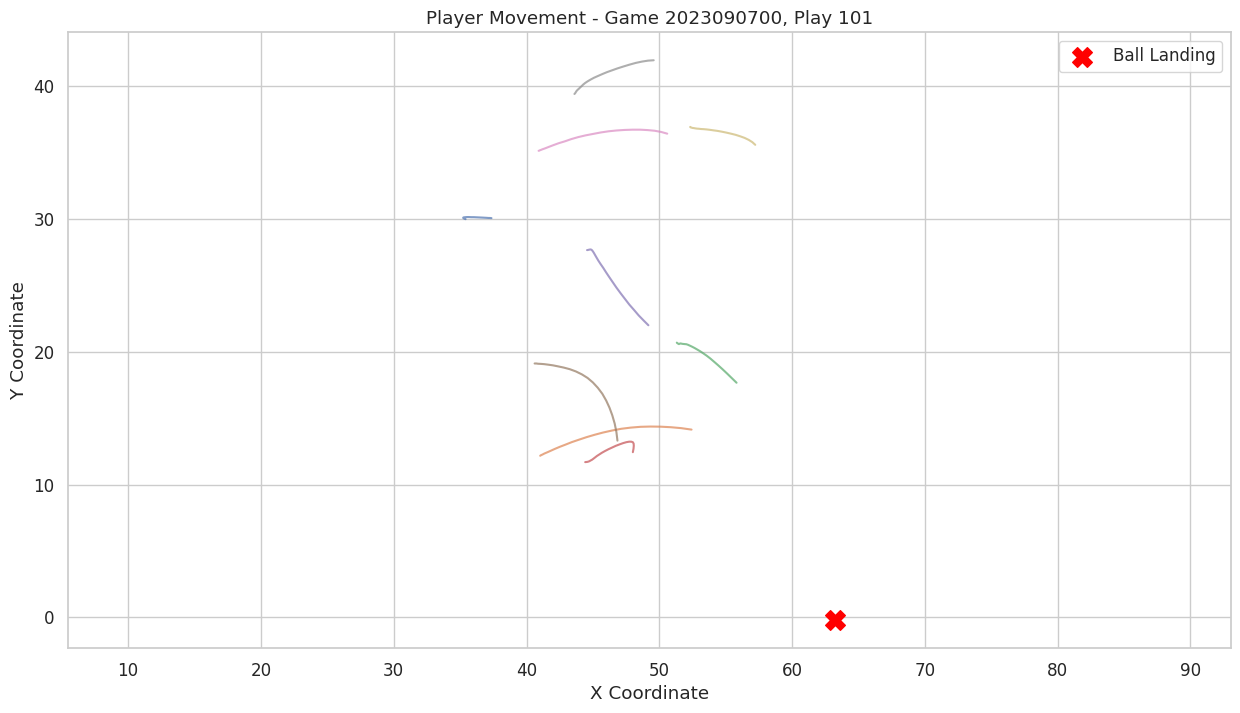

In [10]:
sample_play_df = df_combined[(df_combined['game_id'] == 2023090700) & (df_combined['play_id'] == 101)]

if not sample_play_df.empty:
    plt.figure(figsize=(15, 8))
    for nfl_id in sample_play_df['nfl_id'].unique():
        player_df = sample_play_df[sample_play_df['nfl_id'] == nfl_id]
        plt.plot(player_df[x_col], player_df[y_col], alpha=0.7)

    ball_land_x = sample_play_df['ball_land_x'].iloc[0]
    ball_land_y = sample_play_df['ball_land_y'].iloc[0]
    plt.scatter(ball_land_x, ball_land_y, color='red', marker='X', s=200, label='Ball Landing')

    plt.title('Player Movement - Game 2023090700, Play 101')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.legend()
    plt.axis('equal')
    plt.show()
else:
    print('Sample play data not found.')

---
## 11. Speed by Position

**What we're showing:** Box plot of speed by top 10 player positions.

**Why it matters:** WR and CB show highest speeds - position is a strong signal for movement.

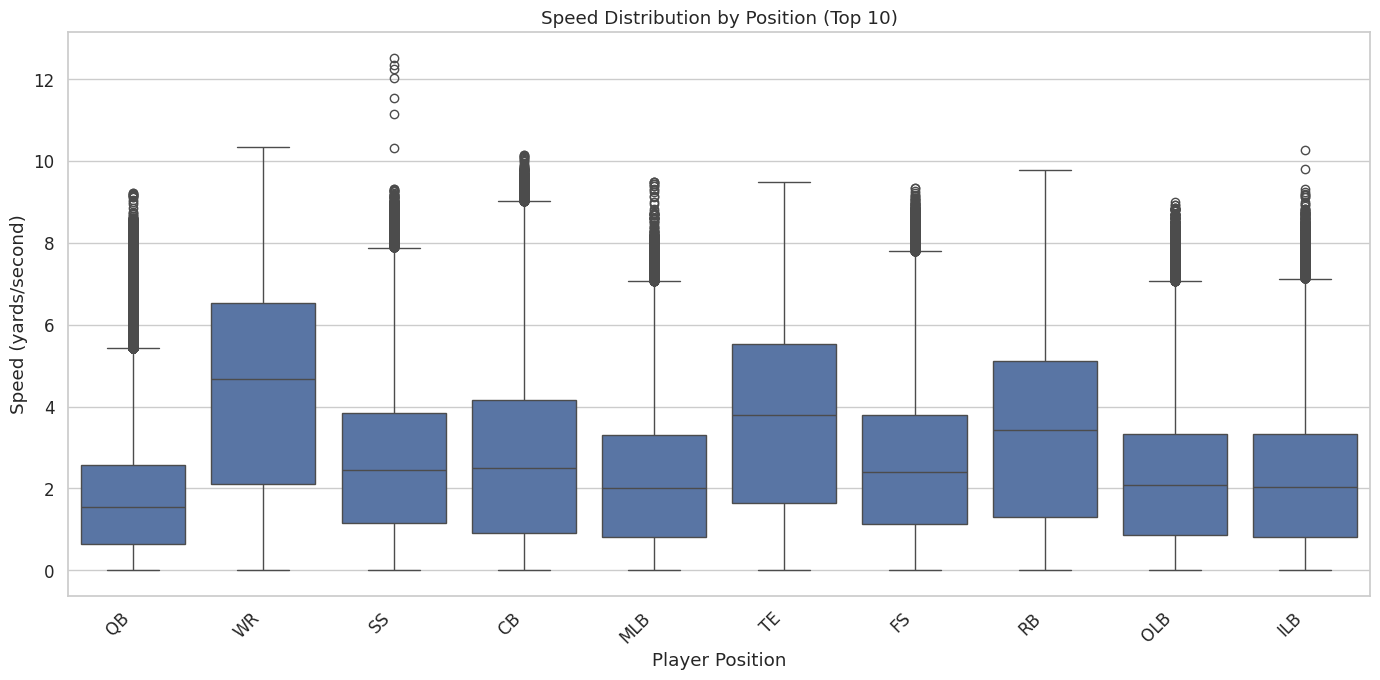

In [11]:
top_n_positions = df_combined['player_position'].value_counts().nlargest(10).index.tolist()
df_top_positions = df_combined[df_combined['player_position'].isin(top_n_positions)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_positions, x='player_position', y='s')
plt.title('Speed Distribution by Position (Top 10)')
plt.xlabel('Player Position')
plt.ylabel('Speed (yards/second)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 12. Displacement Analysis (Prediction Target)

**What we're showing:** The actual prediction target - displacement from current to future position.

**Key Statistics:**
- Mean displacement: 11.01 yards
- Median displacement: 9.74 yards
- 90th percentile: 20.14 yards
- 95th percentile: 23.85 yards
- 99th percentile: 31.04 yards

**Why it matters:** This IS what the model must predict. The right-skewed distribution shows most movements are moderate (~10 yards) but some are extreme (>30 yards).

### Displacement Statistics

,count,mean,std,min,25%,50%,75%,max
displacement_x,560426.00,-0.01,10.42,-45.60,-6.41,0.02,6.36,50.96
displacement_y,560426.00,-0.12,7.54,-42.89,-4.84,-0.14,4.60,42.12
displacement_dist,560426.00,11.01,6.65,0.01,6.05,9.74,14.71,54.64


### Key Percentiles

,Percentile,Distance (yards)
0,50%,9.742513
1,90%,20.140823
2,95%,23.845067
3,99%,31.044194


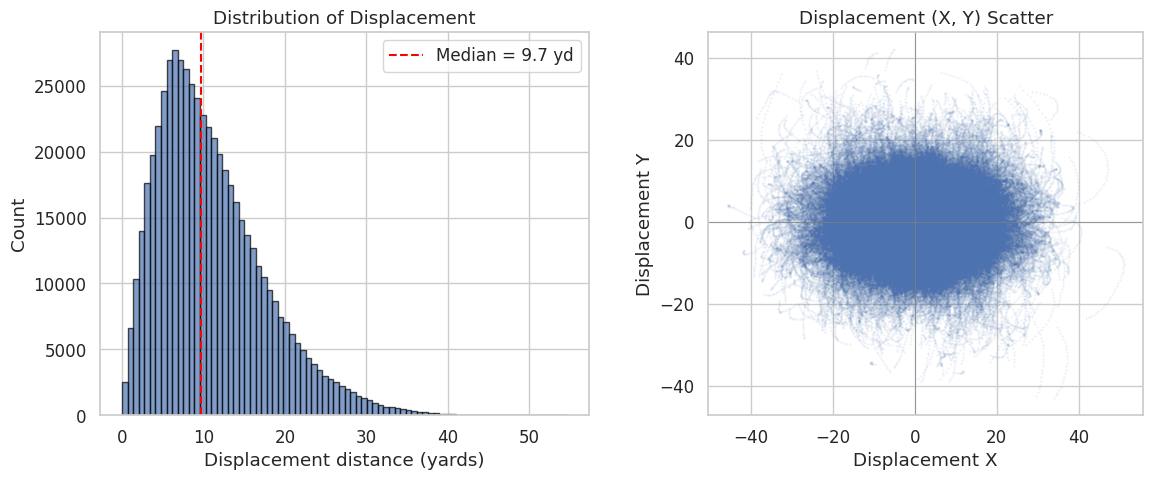

In [12]:
pred = df_combined[df_combined["player_to_predict"] & df_combined["x_output"].notna()].copy()
pred["displacement_x"] = pred["x_output"] - pred["x_input"]
pred["displacement_y"] = pred["y_output"] - pred["y_input"]
pred["displacement_dist"] = np.sqrt(pred["displacement_x"] ** 2 + pred["displacement_y"] ** 2)

display(Markdown('### Displacement Statistics'))
display(pred[["displacement_x", "displacement_y", "displacement_dist"]].describe().T.style.format('{:.2f}').background_gradient(cmap='Purples'))

display(Markdown('### Key Percentiles'))
percentiles = [50, 90, 95, 99]
percentile_df = pd.DataFrame({
    'Percentile': [f'{p}%' for p in percentiles],
    'Distance (yards)': np.percentile(pred["displacement_dist"], percentiles)
})
display(percentile_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(pred["displacement_dist"], bins=80, edgecolor="black", alpha=0.7)
axes[0].axvline(pred["displacement_dist"].median(), color="red", linestyle="--", label=f"Median = {pred['displacement_dist'].median():.1f} yd")
axes[0].set_xlabel("Displacement distance (yards)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Displacement")
axes[0].legend()

axes[1].scatter(pred["displacement_x"], pred["displacement_y"], alpha=0.05, s=1)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_xlabel("Displacement X")
axes[1].set_ylabel("Displacement Y")
axes[1].set_title("Displacement (X, Y) Scatter")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

---
## 13. Play-Level Context (Supplementary Data)

**Dataset:** 18,009 plays with 41 columns

**Pass Result Breakdown:**
- Complete (C): 12,470 (69%)
- Incomplete (I): 5,106 (28%)
- Interception (IN): 433 (2%)

**Top Routes:** HITCH (3,383), OUT (2,886), FLAT (2,490), CROSS (1,957), GO (1,776)

**Why it matters:** Play context can enhance prediction models by conditioning on route type and coverage.

In [13]:
supp_path = DATA_ROOT / "supplementary_data.csv"
if supp_path.exists():
    df_supp = pd.read_csv(supp_path)
    
    display(Markdown(f'### Supplementary Data: {df_supp.shape[0]:,} rows, {df_supp.shape[1]} columns'))
    
    display(Markdown('### Pass Result Distribution'))
    display(df_supp["pass_result"].value_counts().to_frame())
    
    if "route_of_targeted_receiver" in df_supp.columns:
        display(Markdown('### Top 10 Routes'))
        display(df_supp["route_of_targeted_receiver"].value_counts().head(10).to_frame())

    plays_tracking = df_combined[["game_id", "play_id"]].drop_duplicates()
    plays_supp = df_supp[["game_id", "play_id"]].drop_duplicates()
    in_both = plays_tracking.merge(plays_supp, on=["game_id", "play_id"], how="inner")
    
    display(Markdown('### Play Coverage'))
    display(pd.DataFrame({
        'Dataset': ['Tracking', 'Supplementary', 'Matched'],
        'Plays': [len(plays_tracking), len(plays_supp), len(in_both)]
    }))
else:
    print('Supplementary file not found at', supp_path)

/tmp/ipykernel_10384/3310537231.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_supp = pd.read_csv(supp_path)


### Supplementary Data: 18,009 rows, 41 columns

### Pass Result Distribution

,count
pass_result,
C,12470
I,5106
IN,433


### Top 10 Routes

,count
route_of_targeted_receiver,
HITCH,3383
OUT,2886
FLAT,2490
CROSS,1957
GO,1776
IN,1408
SLANT,1316
POST,978
ANGLE,704


### Play Coverage

,Dataset,Plays
0,Tracking,14108
1,Supplementary,18009
2,Matched,14108


---
## Summary

### Key Findings

| Finding | Detail |
|---------|--------|
| Dataset | 4.88M rows, 18 weeks, 560k prediction targets |
| Players to predict | CB: 371k, WR: 239k, FS: 149k |
| Roles | Defensive Coverage: 907k, Targeted Receiver: 397k |
| Speed | Mean 3.04 yards/s, Max 12.53 yards/s |
| Displacement | Median 9.7 yards, 95%ile 23.8 yards |
| Pass results | Complete: 12,470, Incomplete: 5,106, INT: 433 |

### Top 5 Players by Distance Covered

| Player | Avg Speed | Total Distance |
|--------|-----------|----------------|
| Jordan Addison | 4.58 | 5,795.2 |
| CeeDee Lamb | 4.31 | 5,417.9 |
| Amon-Ra St. Brown | 4.43 | 5,370.6 |
| K.J. Osborn | 4.33 | 5,133.8 |
| Terry McLaurin | 4.44 | 5,106.5 |

### Recommended Features for Modeling

- **Velocity vectors**: (vx, vy) from speed and direction
- **Relative positioning**: Distance/angle to ball landing
- **Player context**: Position, role, side
- **Play-level**: Pass result, route type, coverage scheme

---
## Conclusions and Next Steps

### Modeling Recommendations

1. **Sequence models** (LSTM, GRU) for temporal dependencies
2. **Physics-informed models** incorporating velocity/acceleration constraints
3. **Position-specific models** may outperform global models
4. **Ensemble approaches** for robust predictions

### Validation Strategy

- Time-based splits (early weeks for training, later for validation)
- Evaluate separately by position and role
- Monitor error vs displacement distance

### Next Steps

1. Implement feature engineering pipeline
2. Build baseline model with velocity vectors
3. Add complexity with sequence models
4. Ensemble multiple approaches